# 10.1 — Merton estructural y modelos de intensidad

Arranca M10. Dos familias de modelos de crédito con filosofías opuestas: **Merton**
(1974) deriva el default de la estructura de capital de la firma (mecanismo económico
explícito); los **modelos de intensidad** (reducidos) tratan el default como el primer
salto de un proceso de Poisson, sin mecanismo económico, pero calibrables directamente a
spreads de mercado — el enfoque dominante en la práctica de pricing de crédito (M10.2+).

## 0. Configuración

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import brentq
import matplotlib.pyplot as plt

from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 1. Merton estructural

El valor de la firma $V_t$ sigue GBM bajo la medida risk-neutral. La deuda es un bono
cupón cero de cara $D$ a vencimiento $T$: si $V_T\ge D$, los tenedores de deuda reciben
$D$ y el equity recibe $V_T-D$; si $V_T<D$, la firma defaultea, la deuda recibe $V_T$
(todo lo que queda) y el equity recibe 0. El **equity es exactamente una call** sobre
$V_T$ con strike $D$ (Black-Scholes, `qflib.black.bs_price`); la deuda es
$\text{Deuda}_0=V_0-\text{Equity}_0$ (identidad contable — se reparte todo el valor de la
firma). La probabilidad de default risk-neutral es $N(-d_2)$ de la misma fórmula BS.

In [2]:
def merton_equity(V0, D, r, sigma_V, T):
    return bs_price(V0, D, r, 0.0, sigma_V, T, kind="call")


def merton_default_prob(V0, D, r, sigma_V, T):
    d1 = (np.log(V0 / D) + (r + 0.5 * sigma_V ** 2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)
    return norm.cdf(-d2)


V0, D, r, sigma_V, T = 100.0, 80.0, 0.04, 0.25, 5.0
equity0 = merton_equity(V0, D, r, sigma_V, T)
debt0 = V0 - equity0
pd_merton = merton_default_prob(V0, D, r, sigma_V, T)

print(f"equity_0={equity0:.4f}  deuda_0={debt0:.4f}  V0={V0}  (equity+deuda-V0={equity0+debt0-V0:.2e})")
print(f"probabilidad de default (riesgo-neutral): {pd_merton:.4%}")

equity_0=40.2340  deuda_0=59.7660  V0=100.0  (equity+deuda-V0=0.00e+00)
probabilidad de default (riesgo-neutral): 31.6527%


### Demo 1 — probabilidad de default vs apalancamiento y volatilidad de activos

Con la fórmula de Merton fija, variamos un parámetro a la vez y graficamos cómo cambia $N(-d_2)$: primero el apalancamiento $D/V_0$ (a mayor proporción de deuda sobre el valor de la firma, la call del equity queda más OTM y el default es más probable), luego la volatilidad de los activos $\sigma_V$ (a mayor incertidumbre sobre el valor futuro de la firma, más probable que termine por debajo de $D$). Ambos son el mismo mecanismo — la probabilidad de default de Merton es, literalmente, la probabilidad de que una opción termine OTM.

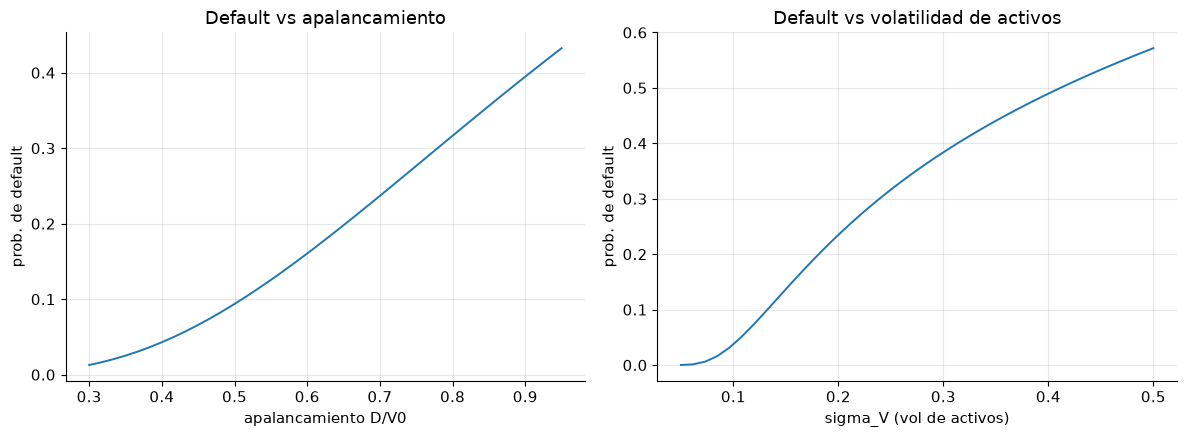

mayor apalancamiento y mayor volatilidad de activos elevan la probabilidad de default --
consistente con la intuicion: firmas mas endeudadas o mas riesgosas defaultean mas seguido.


In [3]:
leverage_grid = np.linspace(0.3, 0.95, 40)
pd_by_leverage = [merton_default_prob(V0, leverage * V0, r, sigma_V, T) for leverage in leverage_grid]

sigma_grid = np.linspace(0.05, 0.5, 40)
pd_by_sigma = [merton_default_prob(V0, D, r, s, T) for s in sigma_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(leverage_grid, pd_by_leverage)
axes[0].set_xlabel("apalancamiento D/V0"); axes[0].set_ylabel("prob. de default")
axes[0].set_title("Default vs apalancamiento")

axes[1].plot(sigma_grid, pd_by_sigma)
axes[1].set_xlabel("sigma_V (vol de activos)"); axes[1].set_ylabel("prob. de default")
axes[1].set_title("Default vs volatilidad de activos")
fig.tight_layout(); plt.show()

print("mayor apalancamiento y mayor volatilidad de activos elevan la probabilidad de default --")
print("consistente con la intuicion: firmas mas endeudadas o mas riesgosas defaultean mas seguido.")

## 2. Modelos de intensidad (reducidos)

El default es el primer salto de un proceso de Poisson con intensidad (hazard rate)
$\lambda_t$: $P(\tau>t)=\exp\left(-\int_0^t\lambda_s\,ds\right)$. Con $\lambda$
**constante**, $P(\tau>t)=e^{-\lambda t}$, simulable exactamente por inversión de CDF
(reusa 0.3): $\tau=-\ln(U)/\lambda$, $U\sim\text{Unif}(0,1)$.

In [4]:
lam_const = 0.02
n_paths = 200_000
U = rng.uniform(size=n_paths)
tau_sim = -np.log(U) / lam_const

t_check = 3.0
surv_sim = np.mean(tau_sim > t_check)
surv_exact = np.exp(-lam_const * t_check)
se_surv = np.sqrt(surv_exact * (1 - surv_exact) / n_paths)
z_const = (surv_sim - surv_exact) / se_surv

print(f"intensidad constante lambda={lam_const}: P(tau>{t_check}) simulada={surv_sim:.5f}, "
      f"exacta={surv_exact:.5f}, z={z_const:.2f}")

intensidad constante lambda=0.02: P(tau>3.0) simulada=0.94148, exacta=0.94176, z=-0.54


### Demo 2 — intensidad determinista dependiente del tiempo

Generalizamos la intensidad constante a $\lambda(t)$ variable en el tiempo (aquí, creciente linealmente — un nombre de crédito cuyo riesgo se deteriora con el horizonte). La supervivencia exacta requiere ahora integrar $\lambda(t)$ ($\int_0^t\lambda(s)ds$, vía cuadratura numérica); para simular, no hay una fórmula cerrada de $\tau=-\ln(U)/\lambda$ como en el caso constante, así que invertimos la CDF generalizada resolviendo $\int_0^\tau\lambda(s)ds=E$ para cada $E\sim\text{Exp}(1)$ (la misma idea de transformada inversa de 0.3, aplicada a una hazard acumulada en vez de a una CDF con forma cerrada).

intensidad lambda(t)=0.01+0.005t: P(tau>4.0) simulada=0.92400, exacta (integracion numerica)=0.92312, z=0.74


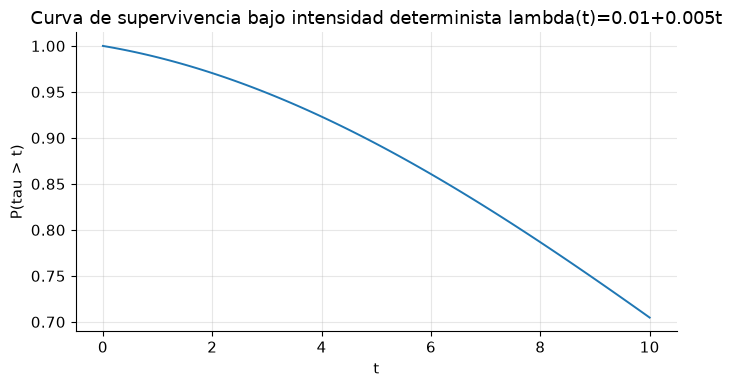

In [5]:
def lam_t(t):
    return 0.01 + 0.005 * t


def cum_hazard(t):
    return quad(lam_t, 0, t)[0]


t_check2 = 4.0
surv_exact2 = np.exp(-cum_hazard(t_check2))

n_paths2 = 50_000
E = rng.exponential(size=n_paths2)  # tau tal que cum_hazard(tau) = E ~ Exp(1) (inversion de CDF generalizada)
tau_sim2 = np.array([brentq(lambda t: cum_hazard(t) - e, 0.0, 200.0) for e in E])

surv_sim2 = np.mean(tau_sim2 > t_check2)
se_surv2 = np.sqrt(surv_exact2 * (1 - surv_exact2) / n_paths2)
z_timedep = (surv_sim2 - surv_exact2) / se_surv2

print(f"intensidad lambda(t)=0.01+0.005t: P(tau>{t_check2}) simulada={surv_sim2:.5f}, "
      f"exacta (integracion numerica)={surv_exact2:.5f}, z={z_timedep:.2f}")

t_grid = np.linspace(0, 10, 100)
surv_curve = np.array([np.exp(-cum_hazard(t)) for t in t_grid])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_grid, surv_curve)
ax.set_xlabel("t"); ax.set_ylabel("P(tau > t)")
ax.set_title("Curva de supervivencia bajo intensidad determinista lambda(t)=0.01+0.005t")
fig.tight_layout(); plt.show()

## 3. El puente: intensidad implícita de Merton

El título de este notebook promete una relación entre las dos familias, y hasta aquí
solo las hemos puesto una al lado de la otra. El puente se construye con lo que ya
tenemos, sin ningún supuesto nuevo: si el modelo estructural dice que la probabilidad de
default a horizonte $T$ es $\text{PD}_{\text{Merton}}(T)=N(-d_2(T))$, esa misma
probabilidad es consistente con un default modelado como el primer salto de un Poisson
de intensidad **constante equivalente** $\lambda_{\text{impl}}(T)$ tal que
$1-\text{PD}_{\text{Merton}}(T)=e^{-\lambda_{\text{impl}}(T)\,T}$, es decir

$$\lambda_{\text{impl}}(T)=-\frac{\ln\!\left(1-\text{PD}_{\text{Merton}}(T)\right)}{T}.$$

Esto NO es la intensidad instantánea del proceso subyacente (Merton no tiene una; el
default ocurre por cruce de barrera de una difusión, no por un salto de Poisson) — es la
intensidad *promedio* que, vista desde un modelo de intensidad constante, reproduce
exactamente la misma probabilidad de supervivencia a ese horizonte $T$. Recorriendo $T$
sobre una malla obtenemos una curva $\lambda_{\text{impl}}(T)$: el "hazard implícito de
Merton" como función del vencimiento — la forma que tendría que tener la curva de hazard
de un modelo de intensidad para ser observacionalmente indistinguible de Merton a cada
horizonte.

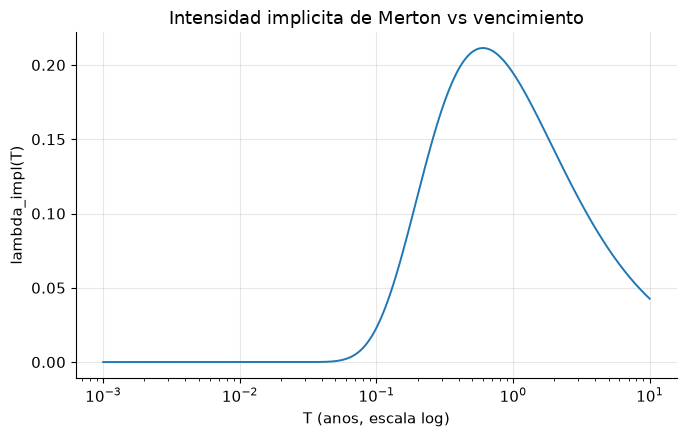

       T       PD_Merton     lambda_impl
   5.000    3.165267e-01    7.611353e-02
   2.000    2.480488e-01    1.425419e-01
   1.000    1.768142e-01    1.945734e-01
   0.500    9.904030e-02    2.085895e-01
   0.250    3.572172e-02    1.455014e-01
   0.100    2.301090e-03    2.303742e-02
   0.050    3.173294e-05    6.346688e-04
   0.020    1.338611e-10    6.693056e-09
   0.010    2.144687e-19    2.144687e-17
   0.005    7.650021e-37    1.530004e-34
   0.001   1.372088e-175   1.372088e-172


In [6]:
T_grid_bridge = np.logspace(-3, 1, 300)  # 0.001 a 10 anos


def lambda_implied(T):
    pd_T = merton_default_prob(V0, D, r, sigma_V, T)
    return -np.log1p(-pd_T) / T  # log1p: estable cuando pd_T es minusculo (T chico)


lambda_impl_curve = np.array([lambda_implied(T) for T in T_grid_bridge])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(T_grid_bridge, lambda_impl_curve)
ax.set_xlabel("T (anos, escala log)"); ax.set_ylabel("lambda_impl(T)")
ax.set_title("Intensidad implicita de Merton vs vencimiento")
fig.tight_layout(); plt.show()

T_report = np.array([5.0, 2.0, 1.0, 0.5, 0.25, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001])
print(f"{'T':>8}  {'PD_Merton':>14}  {'lambda_impl':>14}")
for T in T_report:
    pd_T = merton_default_prob(V0, D, r, sigma_V, T)
    lam = lambda_implied(T)
    print(f"{T:8.3f}  {pd_T:14.6e}  {lam:14.6e}")

### Demo — el *credit spread puzzle* de Merton

La tabla y la curva muestran el punto: $\lambda_{\text{impl}}(T)$ NO es plana. Sube
desde $T=10$ hasta un máximo cerca de $T\approx0.5$ años (donde $\text{PD}_{\text{Merton}}$
todavía es apreciable) y luego se desploma hacia 0 a medida que $T\to0$ — a $T=0.01$ años
(~3.6 días) la intensidad implícita es de orden $10^{-17}$, esencialmente cero. La razón
económica: $V_0=100>D=80$, y una difusión browniana geométrica *continua* no puede cruzar
la barrera $D$ en un intervalo de tiempo infinitesimal — para defaultear en unos pocos
días necesitaría un salto, y no lo tiene. Este es el célebre ***credit spread puzzle***
de Merton: el modelo predice spreads de crédito de cortísimo plazo prácticamente nulos,
mientras que los bonos y CDS de nombres con riesgo de default observable cotizan spreads
de corto plazo claramente positivos (Jones, Mason y Rosenfeld, 1984, documentan que
Merton subestima sistemáticamente los spreads observados, sobre todo en los tenores
cortos).

Contraste directo con 10.2: ahí bootstrapeamos una curva de hazard por tramos desde
spreads CDS de mercado (`spreads_mkt = [1.0%, 1.5%, 2.0%, 2.3%, 2.5%]` a 1/3/5/7/10 años)
y el hazard del primer tramo (0–1 año) salió $\lambda_{0\text{-}1y}\approx1.63\%$ —
un número muy lejos de cero, y del mismo orden que los tramos más largos. Esa es
precisamente la discrepancia que Merton no puede reproducir con un valor de firma
continuo: la curva de hazard de mercado no colapsa a 0 en el corto plazo. Es exactamente
esta brecha la que motivó (i) los modelos de intensidad (10.2), que calibran la curva de
hazard directamente a los spreads observados sin pasar por ningún mecanismo de firma, y
(ii) las extensiones estructurales con saltos en el proceso de valor de la firma (08.6):
un salto puede llevar $V_t$ por debajo de $D$ en cualquier instante, restaurando una
intensidad de corto plazo no nula incluso partiendo de $V_0>D$.

Cerramos el puente con dos chequeos de consistencia: (i) reconstruir la probabilidad de
default desde $\lambda_{\text{impl}}(T)$ vía $1-e^{-\lambda_{\text{impl}}(T)T}$ debe
reproducir exactamente $\text{PD}_{\text{Merton}}(T)$ (es una identidad algebraica, no
una aproximación); (ii) la tendencia $\lambda_{\text{impl}}(T)\to0$ cuando $T\to0$ debe
verse estrictamente en una malla decreciente de vencimientos cortos.

In [7]:
# (i) round-trip: PD reconstruida desde lambda_impl debe reproducir PD_Merton exactamente
pd_roundtrip = 1.0 - np.exp(-lambda_impl_curve * T_grid_bridge)
pd_direct = np.array([merton_default_prob(V0, D, r, sigma_V, T) for T in T_grid_bridge])
max_roundtrip_diff = np.max(np.abs(pd_roundtrip - pd_direct))
print(f"round-trip PD (via lambda_impl) vs PD_Merton directa: max diff={max_roundtrip_diff:.2e}")

# (ii) tendencia a 0 cuando T->0: malla decreciente de vencimientos cortos, por debajo del maximo local
T_short_grid = np.array([0.25, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001])
lambda_short = np.array([lambda_implied(T) for T in T_short_grid])
is_decreasing = np.all(np.diff(lambda_short) < 0)
print(f"\nlambda_impl(T) en malla decreciente de T (T->0): {np.round(lambda_short, 8)}")
print(f"estrictamente decreciente al bajar T: {is_decreasing}")
print(f"lambda_impl(T={T_short_grid[-1]}) = {lambda_short[-1]:.3e} (practicamente 0)")

# hazard de corto plazo de 10.2 (bootstrapeado de spreads CDS de mercado, tramo 0-1y), citado, no importado
lambda_10_2_short_term = 0.01628
print(f"\ncomparacion: lambda_impl(T=1.0)={lambda_implied(1.0):.4f} "
      f"vs hazard de mercado 0-1y de 10.2={lambda_10_2_short_term:.4f}")
print(f"lambda_impl(T=0.05)={lambda_implied(0.05):.2e} -- Merton casi 0 a corto plazo, el mercado NO.")

round-trip PD (via lambda_impl) vs PD_Merton directa: max diff=5.55e-17

lambda_impl(T) en malla decreciente de T (T->0): [1.4550143e-01 2.3037420e-02 6.3467000e-04 1.0000000e-08 0.0000000e+00
 0.0000000e+00 0.0000000e+00]
estrictamente decreciente al bajar T: True
lambda_impl(T=0.001) = 1.372e-172 (practicamente 0)

comparacion: lambda_impl(T=1.0)=0.1946 vs hazard de mercado 0-1y de 10.2=0.0163
lambda_impl(T=0.05)=6.35e-04 -- Merton casi 0 a corto plazo, el mercado NO.


## 4. Validación

Seis chequeos: la identidad contable de Merton (el valor de la firma se reparte exactamente entre equity y deuda, sin residuo — una igualdad algebraica, no un test estadístico); las dos comparaciones de supervivencia simulada vs. fórmula cerrada de las Demos 1 y 2 (dentro de 3 errores estándar, tratando cada supervivencia simulada como una proporción binomial); y tres chequeos del puente de la Sección 3: la identidad de round-trip PD↔λ_impl a precisión de máquina, la tendencia estricta λ_impl(T)→0 cuando T→0, y la positividad de λ_impl en toda la malla.

In [8]:
check1 = abs(equity0 + debt0 - V0) < 1e-10
print(f"1. identidad contable Merton (equity+deuda=V0): diff={equity0+debt0-V0:.2e} (<1e-10? {check1})")

check2 = abs(z_const) <= 3.0
print(f"2. supervivencia (intensidad constante) simulada vs exacta: z={z_const:.2f} (<=3? {check2})")

check3 = abs(z_timedep) <= 3.0
print(f"3. supervivencia (intensidad determinista) simulada vs exacta: z={z_timedep:.2f} (<=3? {check3})")

check4 = max_roundtrip_diff < 1e-10
print(f"4. round-trip PD via lambda_impl reproduce PD_Merton: max diff={max_roundtrip_diff:.2e} (<1e-10? {check4})")

check5 = is_decreasing and lambda_short[-1] < 1e-6
print(f"5. lambda_impl(T) -> 0 cuando T->0 (malla decreciente, estrictamente monotona): {check5}")

check6 = np.all(lambda_impl_curve > 0.0)
print(f"6. lambda_impl(T) positiva en toda la malla: {check6}")

assert check1
assert check2
assert check3
assert check4
assert check5
assert check6
print("\nValidacion completa: 6/6 dentro de tolerancia.")

1. identidad contable Merton (equity+deuda=V0): diff=0.00e+00 (<1e-10? True)
2. supervivencia (intensidad constante) simulada vs exacta: z=-0.54 (<=3? True)
3. supervivencia (intensidad determinista) simulada vs exacta: z=0.74 (<=3? True)
4. round-trip PD via lambda_impl reproduce PD_Merton: max diff=5.55e-17 (<1e-10? True)
5. lambda_impl(T) -> 0 cuando T->0 (malla decreciente, estrictamente monotona): True
6. lambda_impl(T) positiva en toda la malla: True

Validacion completa: 6/6 dentro de tolerancia.


## Referencias

- Merton, R. (1974). *On the Pricing of Corporate Debt: The Risk Structure of Interest
  Rates*. Journal of Finance, 29(2), 449-470.
- Jarrow, R., Turnbull, S. (1995). *Pricing Derivatives on Financial Securities Subject to
  Credit Risk*. Journal of Finance, 50(1), 53-85.
- Jones, E., Mason, S., Rosenfeld, E. (1984). *Contingent Claims Analysis of Corporate
  Capital Structures: An Empirical Investigation*. Journal of Finance, 39(3), 611-625 —
  documenta que Merton subestima sistemáticamente los spreads de crédito observados, el
  *credit spread puzzle*.
- Huang, J., Huang, M. (2012). *How Much of the Corporate-Treasury Yield Spread Is Due to
  Credit Risk?*. Review of Asset Pricing Studies, 2(2), 153-202 — cuantifica cuánto del
  spread de corto plazo observado los modelos estructurales clásicos dejan sin explicar.